# Data Preprocessing & Feature Engineering

# 1. Objective 

Transform raw interaction data into:

𝑅
∈
𝑅
𝑚
×
𝑛
R∈R
m×n

and prepare:

clean dataset

encoded features

train/test split

model-ready format

In [12]:
#Load Clean Dataset

import pandas as pd

df = pd.read_csv("../data/processed/ratings_clean.csv")
df.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [8]:
#Data Cleaning (Strict)
#Check missing values
df.isnull().sum()

user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

In [9]:
#Remove duplicates
df = df.drop_duplicates()

In [10]:
#Validate rating range
df['rating'].unique()

array([3, 1, 2, 4, 5])

In [11]:
#Convert to Implicit Feedback
df['interaction'] = (df['rating'] >= 4).astype(int)

# Feature Engineering

In [13]:
#Encode Users & Items 
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df['user_id_enc'] = user_encoder.fit_transform(df['user_id'])
df['item_id_enc'] = item_encoder.fit_transform(df['item_id'])

In [14]:
#Save Encoders 
import pickle

with open("../data/processed/user_encoder.pkl", "wb") as f:
    pickle.dump(user_encoder, f)

with open("../data/processed/item_encoder.pkl", "wb") as f:
    pickle.dump(item_encoder, f)

In [16]:
print(df.columns)

Index(['user_id', 'item_id', 'rating', 'timestamp', 'user_id_enc',
       'item_id_enc'],
      dtype='object')


In [17]:
df['interaction'] = (df['rating'] >= 4).astype(int)

In [18]:
print(df[['rating', 'interaction']].head())

   rating  interaction
0       3            0
1       3            0
2       1            0
3       2            0
4       1            0


In [19]:
df['interaction'].value_counts()

interaction
1    55375
0    44625
Name: count, dtype: int64

In [ ]:
#Build Interaction Matrix
import numpy as np

num_users = df['user_id_enc'].nunique()
num_items = df['item_id_enc'].nunique()

interaction_matrix = np.zeros((num_users, num_items))

interaction_matrix[
    df['user_id_enc'],
    df['item_id_enc']
] = df['interaction']

In [21]:
#Verify Matrix (Do NOT Skip)
print(interaction_matrix.shape)
print(np.sum(interaction_matrix))  # number of positive interactions

(943, 1682)
55375.0


In [22]:
df.to_csv("../data/processed/ratings_final.csv", index=False)

In [23]:
#Train-Test Split 
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [24]:
#Interaction Distribution
df['interaction'].value_counts()

interaction
1    55375
0    44625
Name: count, dtype: int64

In [25]:
#Top Users
df.groupby('user_id_enc').size().sort_values(ascending=False).head()

user_id_enc
404    737
654    685
12     636
449    540
275    518
dtype: int64

In [26]:
#Top Items
df.groupby('item_id_enc').size().sort_values(ascending=False).head()

item_id_enc
49     583
257    509
99     508
180    507
293    485
dtype: int64

In [27]:
#Sparsity Re-check
sparsity = 1 - (df.shape[0] / (num_users * num_items))
print(sparsity)

0.9369533063577546


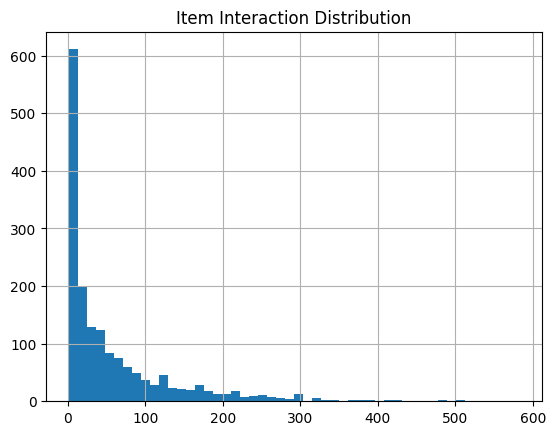

In [ ]:
#Visualization (Report-Level)
import matplotlib.pyplot as plt

df.groupby('item_id_enc').size().hist(bins=50)
plt.title("Item Interaction Distribution")
plt.show()